In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv('..//Data/bank.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
# Setting feature (X) and targets(Y)
X = df.drop(columns=["isFraud",'step','nameOrig','nameDest','isFlaggedFraud'])
X=pd.get_dummies(data=X, columns=['type'])
Y= df["isFraud"]

#TrainTestSplit
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)

#Setting the RandomForest for the regular data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)


# Calculate the prediction and scores
y_pred = rf.predict(X_test)
confusion = confusion_matrix(Y_test, y_pred)
class_report = classification_report(Y_test, y_pred)

print("Confusion Matrix \n", confusion)
print("\nClassification Report\n", class_report)

Confusion Matrix 
 [[1270859      45]
 [    341    1279]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.97      0.79      0.87      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.89      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



In [5]:
# Setting the DecisionTree with the regular data
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
# Calculate the prediction and scores
y_pred_dt = dt.predict(X_test)
confusion_dt = confusion_matrix(Y_test, y_pred_dt)
class_report_dt = classification_report(Y_test, y_pred_dt)

print("Confusion Matrix \n", confusion_dt)
print("\nClassification Report\n", class_report_dt)

Confusion Matrix 
 [[1270764     140]
 [    158    1462]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.91      0.90      0.91      1620

    accuracy                           1.00   1272524
   macro avg       0.96      0.95      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



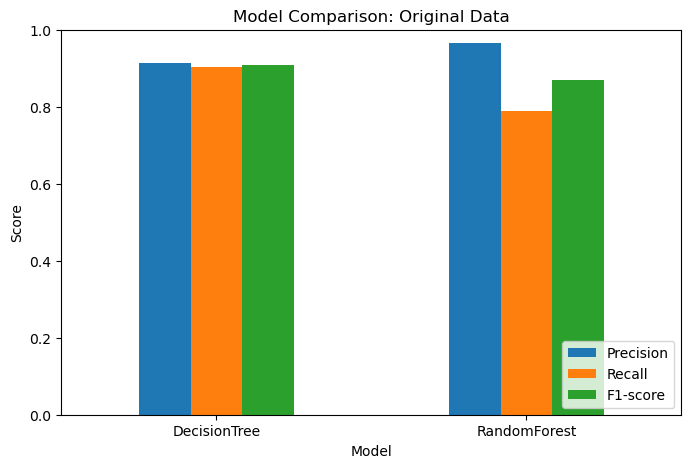

In [15]:
from sklearn.metrics import precision_recall_fscore_support

p1, r1, f1, _ = precision_recall_fscore_support(Y_test, y_pred_dt, average='binary')
p2, r2, f2, _ = precision_recall_fscore_support(Y_test, y_pred, average='binary')

metrics = pd.DataFrame({
    'Model': ['DecisionTree','RandomForest'],
    'Precision': [p1, p2],
    'Recall': [r1, r2],
    'F1-score': [f1, f2]
})

metrics.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title('Model Comparison: Original Data')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

Among the original data, DecisionTree DT have better performance than RandomForest RF.
Though the RF have higher Precision, but DT detects more true fraud, which in fraud detection case, makes the DT model a better choice. And the change in precision isn't too high, so it will not cause too much confusion and noise with customers. 

In [24]:
df2=pd.read_csv('..//Data/bank_cleaned_2.csv')

In [25]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   amount                float64
 1   oldbalanceOrg         float64
 2   newbalanceOrig        float64
 3   oldbalanceDest        float64
 4   newbalanceDest        float64
 5   isFraud               int64  
 6   transfer_percent      float64
 7   amount_to_dest_ratio  float64
 8   IdFrequency           int64  
 9   type_CASH_IN          bool   
 10  type_CASH_OUT         bool   
 11  type_DEBIT            bool   
 12  type_PAYMENT          bool   
 13  type_TRANSFER         bool   
dtypes: bool(5), float64(7), int64(2)
memory usage: 467.2 MB


In [26]:
# Setting feature (X) and targets(Y)
X2 = df2.drop(columns=["isFraud"])
Y2= df2["isFraud"]

#TrainTestSplit
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2,Y2, test_size = 0.2, random_state=42, stratify=Y)


#RandomForest for cleaned-2 data
rf2 = RandomForestClassifier(random_state=42)

# Fit the classifier to the data
rf2.fit(X2_train, Y2_train)

# Calculate the prediction and scores
y_pred_2 = rf2.predict(X2_test)
print(confusion_matrix(Y2_test, y_pred_2))
print(classification_report(Y2_test, y_pred_2))

[[1270880       1]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



(Just side note when this is ran, I am truly surprised!!)

In [27]:
# Setting the DecisionTree with the cleaned-2 data
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X2_train, Y2_train)
# Calculate the prediction and scores
y_pred_dt2 = dt2.predict(X2_test)
confusion_dt2 = confusion_matrix(Y2_test, y_pred_dt2)
class_report_dt2 = classification_report(Y2_test, y_pred_dt2)

print("Confusion Matrix \n", confusion_dt2)
print("\nClassification Report\n", class_report_dt2)

Confusion Matrix 
 [[1270873       8]
 [      6    1637]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



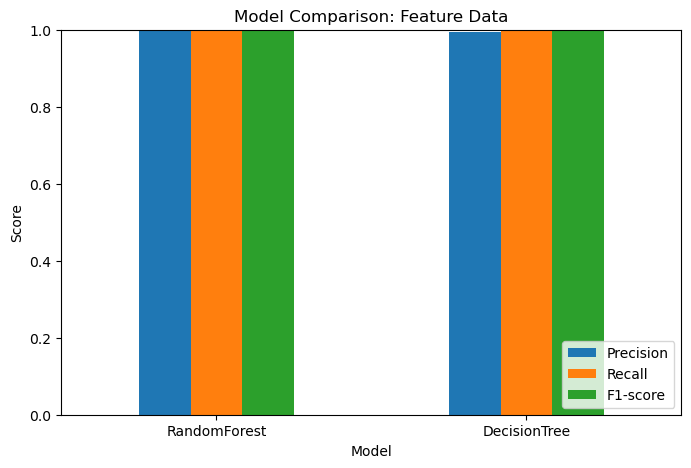

In [28]:
from sklearn.metrics import precision_recall_fscore_support

p1, r1, f1, _ = precision_recall_fscore_support(Y2_test, y_pred_2, average='binary')
p2, r2, f2, _ = precision_recall_fscore_support(Y2_test, y_pred_dt2, average='binary')

metrics = pd.DataFrame({
    'Model': ['RandomForest','DecisionTree'],
    'Precision': [p1, p2],
    'Recall': [r1, r2],
    'F1-score': [f1, f2]
})

metrics.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title('Model Comparison: Feature Data')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

I can't express my happiness when the model ran so well.
The RandomForest model does the best since only 4 false negative and 8 false postive.
The DecisionTree model have 6 false negative and 8 false postive.
I believe over 1m transactions in 

In [23]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary'
    )
    
    return precision, recall, f1

results = []

# Raw dataset models
p, r, f = get_metrics(dt, X_test, Y_test)
results.append(["Decision Tree (Original)", p, r, f])

p, r, f = get_metrics(rf, X_test, Y_test)
results.append(["Random Forest (Original)", p, r, f])

# Cleaned dataset models
p, r, f = get_metrics(dt2, X2_test, Y2_test)
results.append(["Decision Tree (Feature)", p, r, f])

p, r, f = get_metrics(rf2, X2_test, Y2_test)
results.append(["Random Forest (Feature)", p, r, f])

# Convert to DataFrame
df_results = pd.DataFrame(results, columns=["Model", "Precision", "Recall", "F1"])
df_results

,Model,Precision,Recall,F1
0,Decision Tree (Original),0.912609,0.902469,0.907511
1,Random Forest (Original),0.966012,0.789506,0.868886
2,Decision Tree (Feature),0.896319,0.889227,0.892759
3,Random Forest (Feature),0.971229,0.760195,0.852851
